<a href="https://colab.research.google.com/github/marantmir/pos_graduacao_ia_aplicada_sesi_senai_sc/blob/main/LSTM_Pipeline_S%C3%A9ries_temporais_multivariadas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ==============================================
# 1️⃣ Importar bibliotecas
# ==============================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_absolute_error, mean_squared_error
import math


In [ ]:
# ==============================================
# 2️⃣ Gerar dados multivariados sintéticos
# ==============================================
# Suponha sensores de uma estação meteorológica:
# temperatura (°C), umidade (%), e pressão (hPa)

np.random.seed(42)
time = np.arange(0, 1000, 1)

# Padrões simulados com ruído
temp = 25 + 2*np.sin(time/50) + np.random.normal(0, 0.3, len(time))
humid = 60 + 5*np.sin(time/30 + 1) + np.random.normal(0, 1, len(time))
press = 1013 + 3*np.sin(time/100 + 2) + np.random.normal(0, 0.5, len(time))

# Montar DataFrame
data = pd.DataFrame({
    'temperature': temp,
    'humidity': humid,
    'pressure': press
})

data.head()


,temperature,humidity,pressure
0,25.149014,65.606710,1015.390303
1,24.998518,65.219685,1015.643012
2,25.274285,64.437606,1015.306170
3,25.576837,63.809100,1015.535236
4,25.089583,65.227370,1014.728979


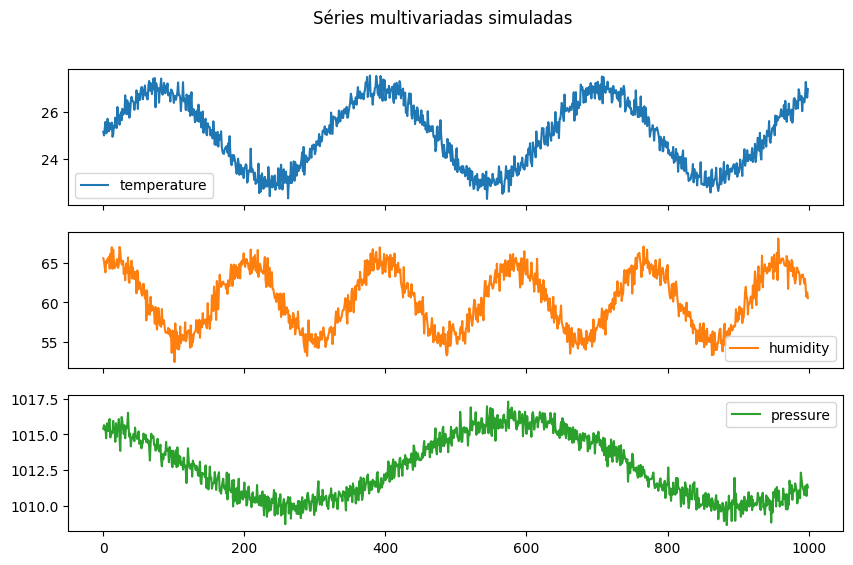

In [ ]:
# ==============================================
# 3️⃣ Visualizar as séries
# ==============================================
data.plot(subplots=True, figsize=(10,6), title="Séries multivariadas simuladas")
plt.show()


In [ ]:
# ==============================================
# 4️⃣ Normalização multivariada
# ==============================================
# A normalização é feita em TODAS as features simultaneamente
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

data_scaled = pd.DataFrame(data_scaled, columns=data.columns)
data_scaled.head()


,temperature,humidity,pressure
0,0.542934,0.840181,0.779726
1,0.514535,0.815560,0.809013
2,0.566574,0.765808,0.769975
3,0.623666,0.725825,0.796523
4,0.531719,0.816049,0.703081


In [ ]:
# ==============================================
# 5️⃣ Criar janelas de tempo (função multivariada)
# ==============================================
#X: janelas de 10 timesteps com todas as features (temperatura, umidade e pressão).
#y: a variável-alvo (temperatura) do próximo instante. Assim, a LSTM aprende como as demais variáveis ajudam a prever a temperatura.
def create_multivariate_sequences(data, window_size=10, horizon=1):
    X, y = [], []
    for i in range(len(data) - window_size - horizon + 1):
        X.append(data[i:(i+window_size), :])          # todas as features
        y.append(data[i+window_size:i+window_size+horizon, 0])  # prever temperatura
    return np.array(X), np.array(y)

window_size = 10
horizon = 1

X, y = create_multivariate_sequences(data_scaled.values, window_size, horizon)
print("Formato X:", X.shape, "| Formato y:", y.shape)


Formato X: (990, 10, 3) | Formato y: (990, 1)


In [ ]:
# ==============================================
# 6️⃣ Split temporal (sem embaralhar!)
# ==============================================
train_size = int(0.8 * len(X))
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print(f"Treino: {X_train.shape}, Teste: {X_test.shape}")


Treino: (792, 10, 3), Teste: (198, 10, 3)


In [ ]:
# ==============================================
# 7️⃣ Construção do modelo LSTM multivariado
# ==============================================
# input_shape=(window_size, X.shape[2]): → 10 passos de tempo × 3 variáveis.
# A rede aprende dependências temporais e cruzadas entre features.
# Dense(horizon): previsão do próximo valor da temperatura.
model = Sequential([
    LSTM(64, input_shape=(window_size, X.shape[2]), return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(horizon)
])

model.compile(loss='mse', optimizer=Adam(0.001))
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        17,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,521 (76.25 KB)

 Trainable params: 19,521 (76.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 0.1956 - val_loss: 0.0110
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0199 - val_loss: 0.0038
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0097 - val_loss: 0.0034
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0072 - val_loss: 0.0051
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0085 - val_loss: 0.0035
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0078 - val_loss: 0.0037
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0071 - val_loss: 0.0035
Epoch 8/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0067 - val_loss: 0.0034
Epoch 9/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0063 - val_loss: 0.0038
Epoch 10/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0071 - val_loss: 0.0042
Epoch 11/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0066 - val_loss: 0.0037
Epoch 12/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0063 - 

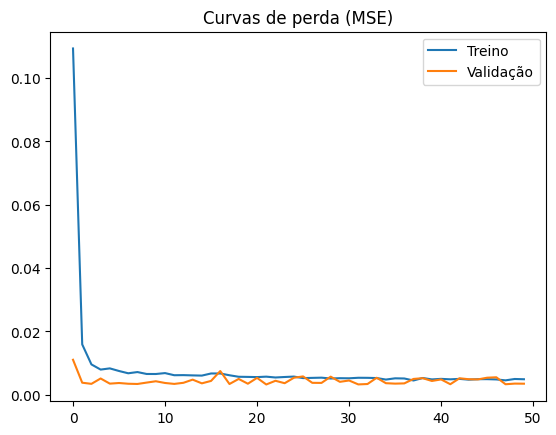

In [ ]:
# ==============================================
# 8️⃣ Treinamento
# ==============================================
history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=50,
    batch_size=32,
    verbose=1
)

plt.plot(history.history['loss'], label='Treino')
plt.plot(history.history['val_loss'], label='Validação')
plt.legend()
plt.title("Curvas de perda (MSE)")
plt.show()


MAE: 0.297 | RMSE: 0.367


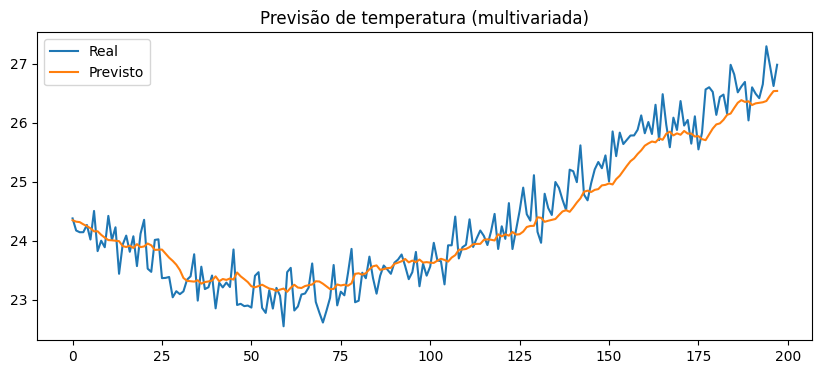

In [ ]:
# Índice da variável que queremos prever (temperatura)
target_col = 0

# Criar matrizes completas para inversão
y_pred_full = np.zeros((len(y_pred), data.shape[1]))
y_test_full = np.zeros((len(y_test), data.shape[1]))

# Colocar a coluna da variável alvo
y_pred_full[:, target_col] = y_pred[:, 0]
y_test_full[:, target_col] = y_test[:, 0]

# Inverter a normalização
y_pred_inv = scaler.inverse_transform(y_pred_full)[:, target_col]
y_test_inv = scaler.inverse_transform(y_test_full)[:, target_col]

# Avaliação
mae = mean_absolute_error(y_test_inv, y_pred_inv)
rmse = math.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
print(f"MAE: {mae:.3f} | RMSE: {rmse:.3f}")

# Visualização
plt.figure(figsize=(10,4))
plt.plot(y_test_inv[:200], label='Real')
plt.plot(y_pred_inv[:200], label='Previsto')
plt.legend()
plt.title("Previsão de temperatura (multivariada)")
plt.show()


In [ ]:
# ==============================================
# 🔟 Hiperparametrização e horizonte de previsão
# ==============================================
# Hiperparâmetros mais importantes:
# - window_size: contexto temporal (quanto maior, mais memória)
# - horizon: quantos passos à frente prever
# - n_neurons: capacidade da LSTM
# - dropout_rate: controle de overfitting
# - learning_rate: taxa de aprendizado
#
# Para tunar automaticamente:
# - usar KerasTuner, Optuna ou RandomizedSearchCV com TimeSeriesSplit
#
# Exemplo: horizon=3 para prever os próximos 3 segundos
window_size = 20
horizon = 3
X2, y2 = create_multivariate_sequences(data_scaled, window_size, horizon, target_col)
X2_train, X2_test = X2[:800], X2[800:]
y2_train, y2_test = y2[:800], y2[800:]

model2 = Sequential([
    LSTM(64, input_shape=(window_size, n_features)),
    Dense(horizon)
])
model2.compile(loss='mse', optimizer=Adam(0.001))
model2.fit(X2_train, y2_train, epochs=30, batch_size=32, verbose=0)
pred2 = model2.predict(X2_test)
print("Previsão para os próximos 3 instantes (exemplo):")
print(scaler.inverse_transform(
    np.concatenate([pred2[0].reshape(1,-1),
                    np.zeros((1, n_features - horizon))], axis=1)
))
